# Mathraining country yearly analytics (V2)

**Part 1** – Download the report (run pipeline) and save the data to a pickle file.  
**Part 2** – Load a saved report and run custom analysis/plots (cumulative bar charts, per-year, by gender, top students). No scraping in Part 2.

In [1]:
%matplotlib inline
import logging
logging.basicConfig(level=logging.INFO, format='%(message)s')
import mathraining_scraping_utils as msu
import pandas as pd

# Country to analyze (48 = Côte d'Ivoire)
country_id = 48

Note: NumExpr detected 10 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 8.
NumExpr defaulting to 8 threads.
/Users/mohamedkane/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


## Part 1: Download report and save

Run the pipeline once to fetch all data, then save the data (no figures) to a pickle file so Part 2 can load it without re-scraping.

In [2]:
#report = msu.build_country_yearly_report(country_id=country_id, sleep_seconds=0.4)

#print("Inferred:", report["country_count"], "users,", report["num_pages"], "pages")
#print("First year in series:", report["first_year"])
#print("Profiles scraped:", len(report["profiles_df"]))
#print("Resolution events:", len(report["events_df"]))

## Save report data to pickle

Saves only the data part of the report (no figures) so you can re-run analyses without scraping again.

In [3]:
# Save data to pickle (run after report is built)
PICKLE_PATH = "report_data.pkl"
#msu.save_report_data(report, PICKLE_PATH)

## Part 2: Load saved report and custom analysis

Load the pickle file and build all figures from the saved data. You can customize plots using the DataFrames below and helpers like `msu.plot_cumulative_single_bar(report_loaded["yearly_metrics_df"], "cumulative_points_eoy")`.

Loaded report data from report_data.pkl


Loaded. First year: 2018 | Profiles: 412 | Events: 20792


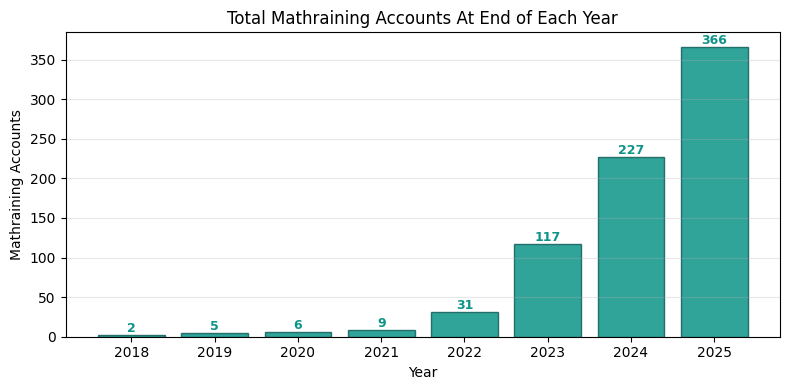

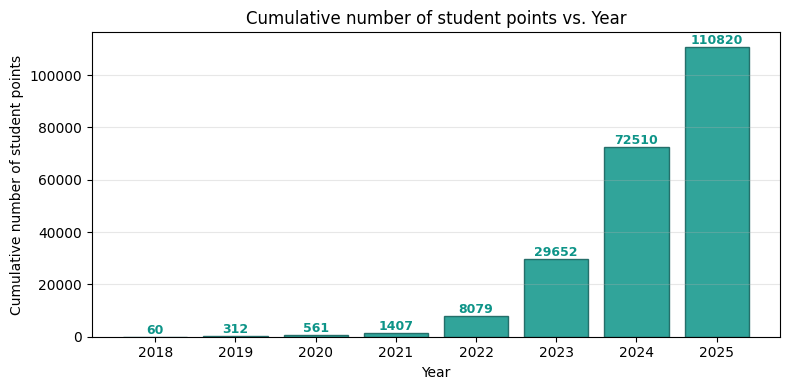

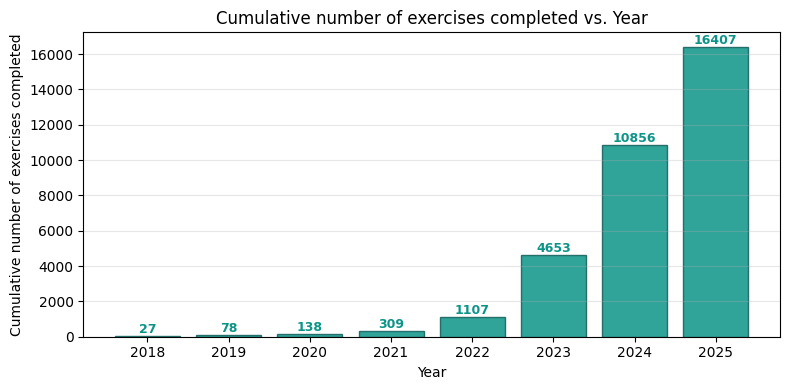

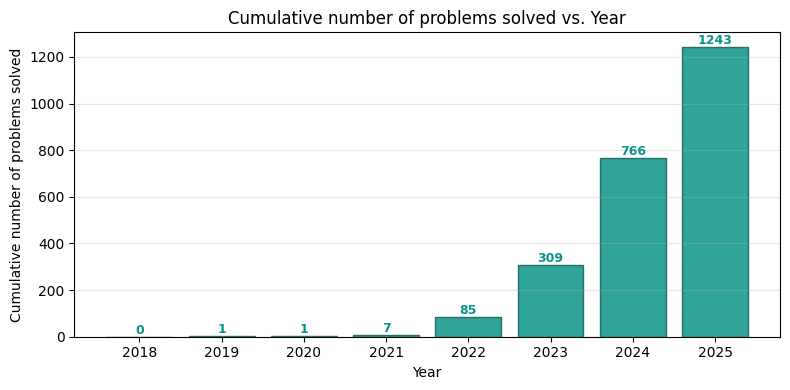

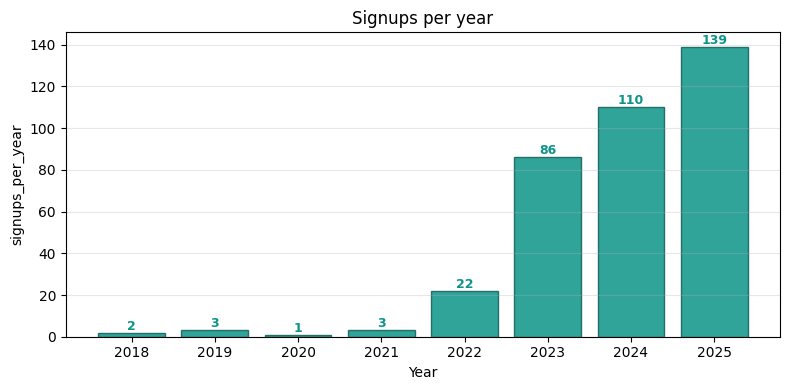

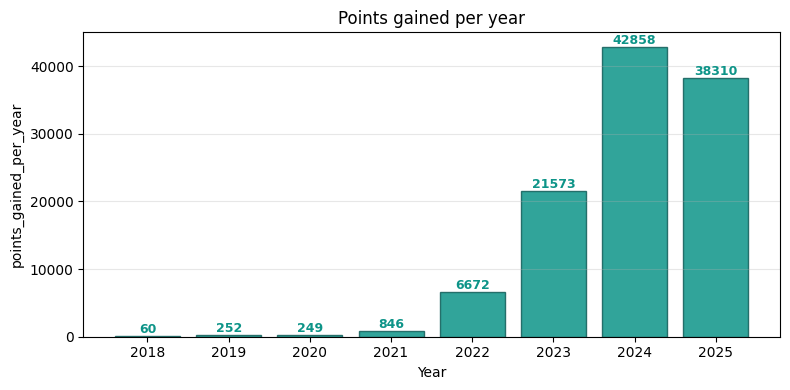

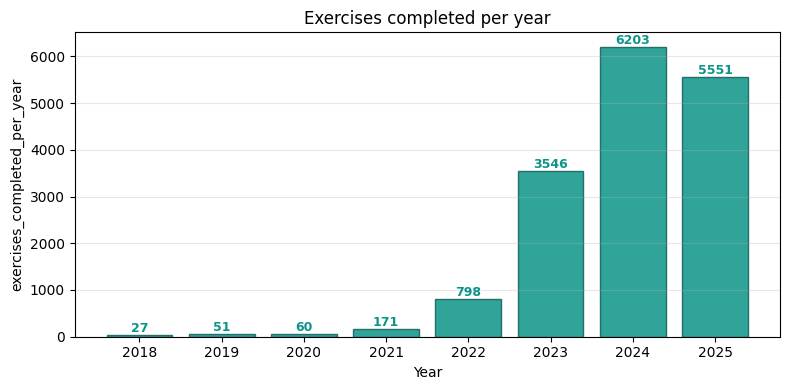

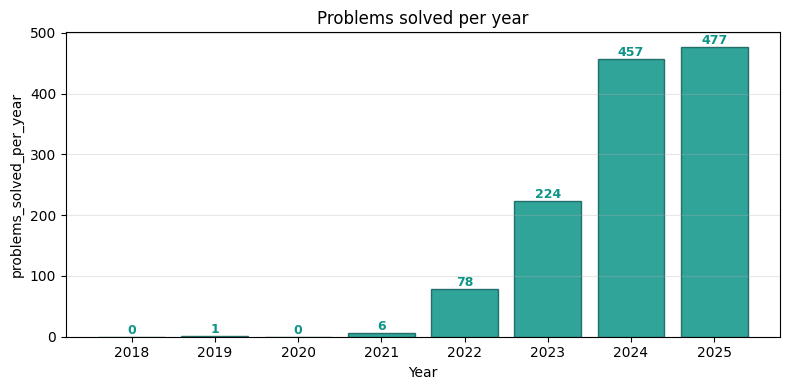

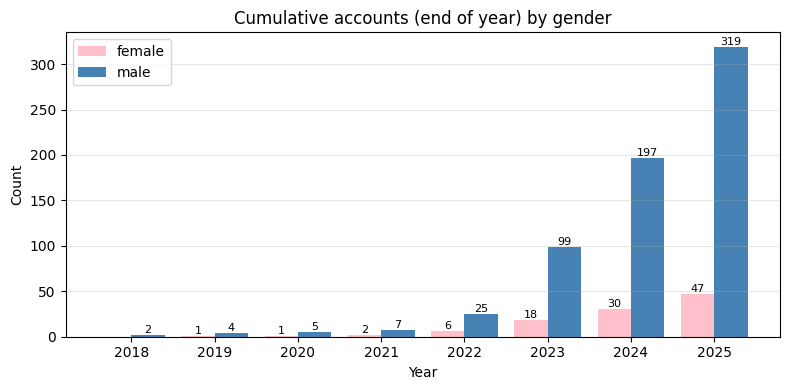

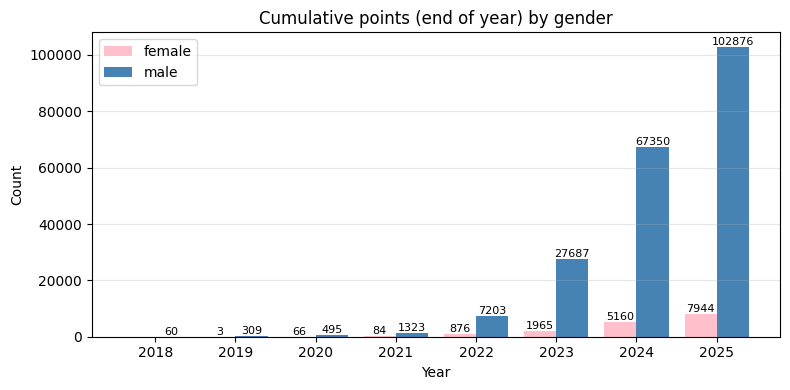

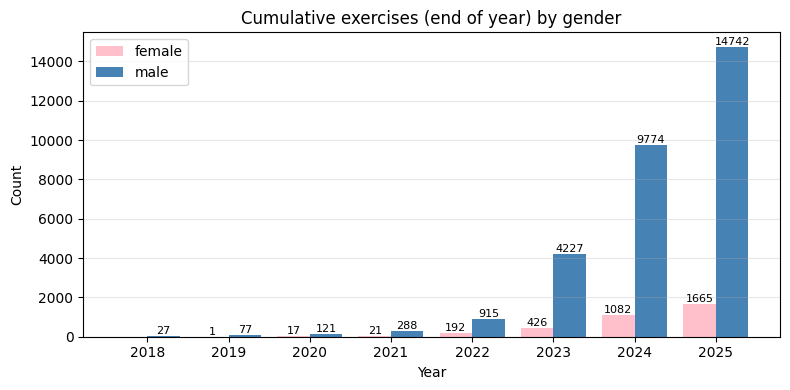

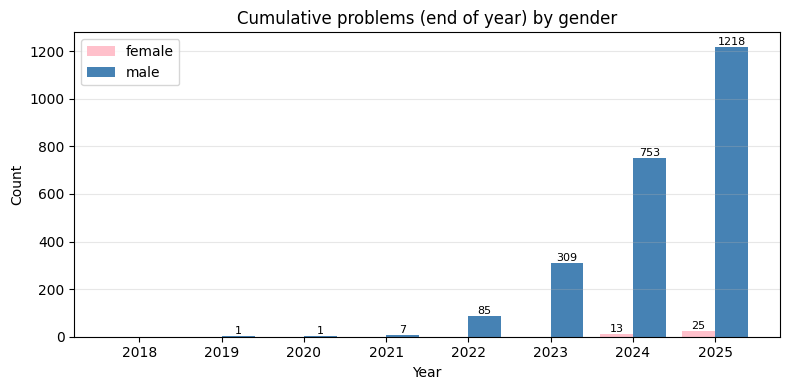

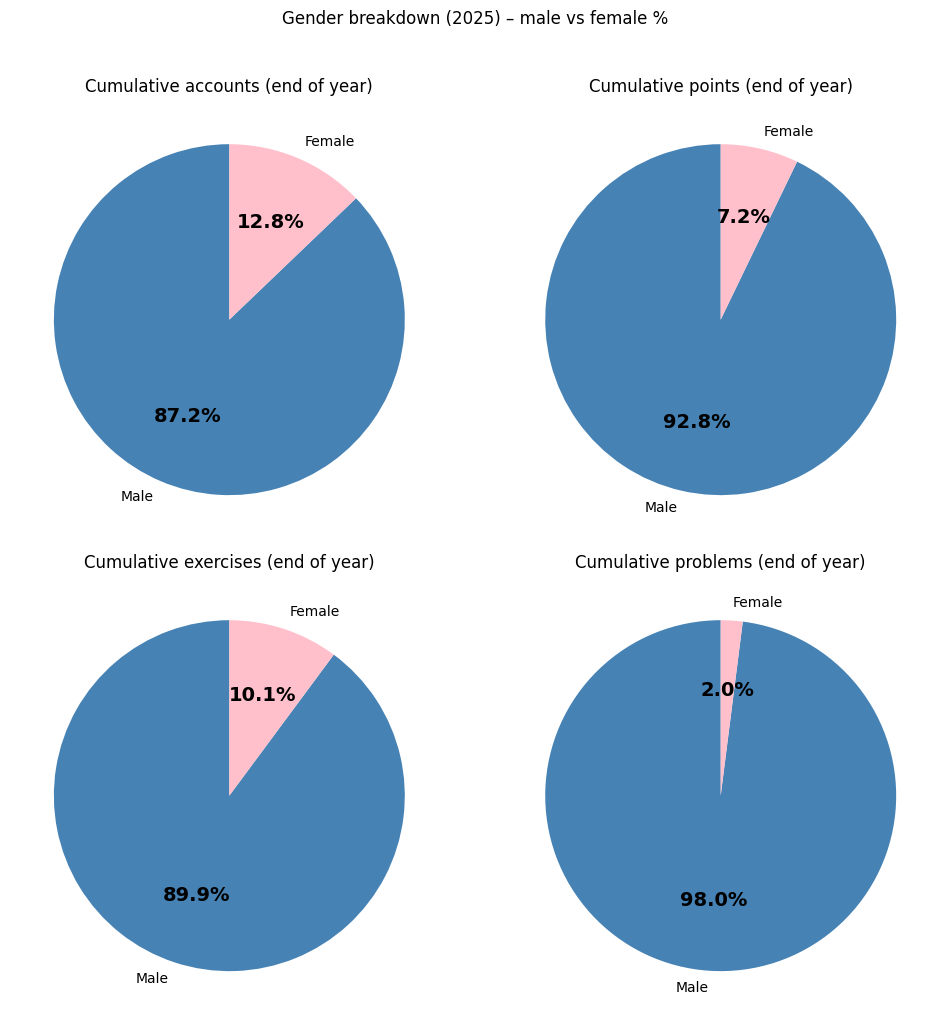

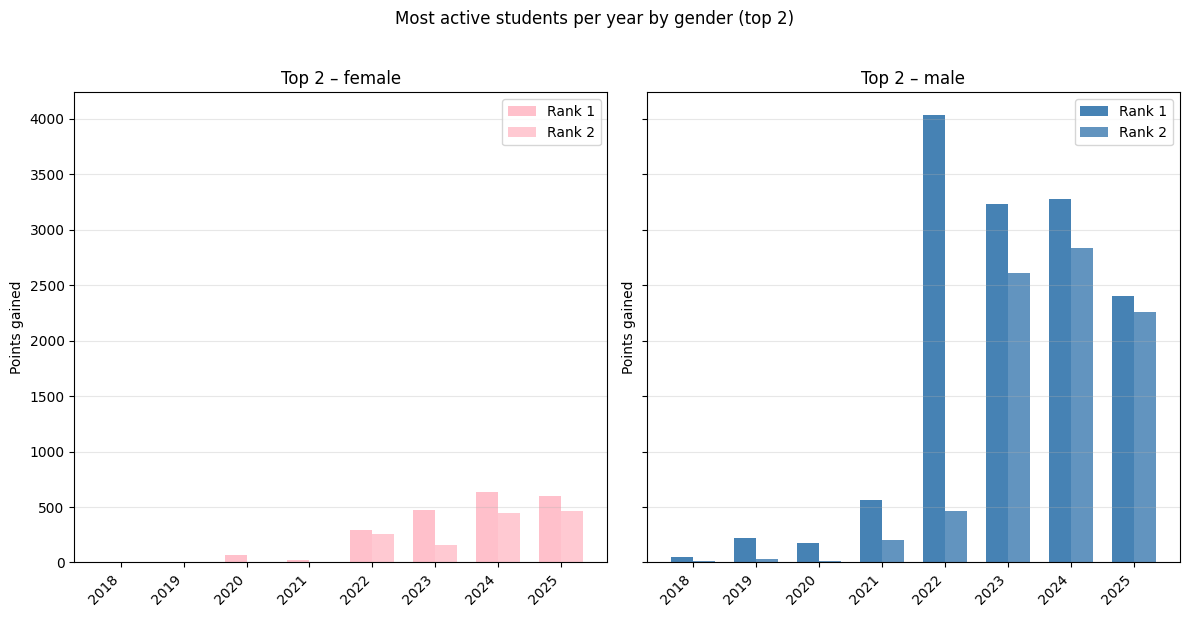

In [4]:
# Load saved data and build all figures (no scraping)
data = msu.load_report_data(PICKLE_PATH)
report_loaded = msu.build_report_from_data(data)
print("Loaded. First year:", report_loaded["first_year"], "| Profiles:", len(report_loaded["profiles_df"]), "| Events:", len(report_loaded["events_df"]))

### Available data for custom plots

The `report_loaded` dict contains DataFrames and figures. Use these to build your own plots in the notebook:

- **`report_loaded["yearly_metrics_df"]`** – One row per year: `year`, `signups_per_year`, `cumulative_accounts_eoy`, `cumulative_points_eoy`, `cumulative_exercises_eoy`, `cumulative_problems_eoy`, and per-year columns.
- **`report_loaded["yearly_metrics_by_gender_df"]`** – Long form: `year`, `gender`, `metric`, `value`.
- **`report_loaded["profiles_df"]`** – Name, Link, Score, Sign Up Date, `gender_inferred`, etc.
- **`report_loaded["events_df"]`** – Resolution events: `year`, `points`, `event_type`, etc.

Helpers: `msu.plot_cumulative_single_bar(df, "cumulative_points_eoy")`, `msu.plot_per_year_single(df, "signups_per_year")`, `msu.plot_cumulative_by_gender_bar(df_gender, "cumulative_accounts_eoy")`.

In [5]:
# Optional: print full data description
print(msu.get_report_data_description())


**Report dict keys (data):**
- `profiles_df` – One row per user: Name, Link, Score, Exercises Completed, Problems Solved, Sign Up Date, gender_inferred
- `events_df` – Resolution events: Name, Link, event_dt, year, points, event_type (exercise/problem)
- `yearly_metrics_df` – One row per year: year, signups_per_year, cumulative_accounts_eoy, points_gained_per_year, cumulative_points_eoy, exercises_completed_per_year, cumulative_exercises_eoy, problems_solved_per_year, cumulative_problems_eoy
- `yearly_metrics_by_gender_df` – Long form: year, gender, metric, value
- `most_active_by_year_df` – year, Name, points_gained
- `most_active_by_year_gender_df` – year, gender, Name, points_gained
- `most_active_top3_df` – year, Name, points_gained, rank (1–3)
- `most_active_top2_by_gender_df` – year, gender, Name, points_gained, rank (1–2)
- `first_year`, `country_count`, `num_pages` – scalars

**Custom plots:** Use `yearly_metrics_df` or `yearly_metrics_by_gender_df` with `msu.plot_cumulative_s

### Cumulative plots (bar layout, with value labels)

One bar chart per cumulative metric, matching the reference layout.

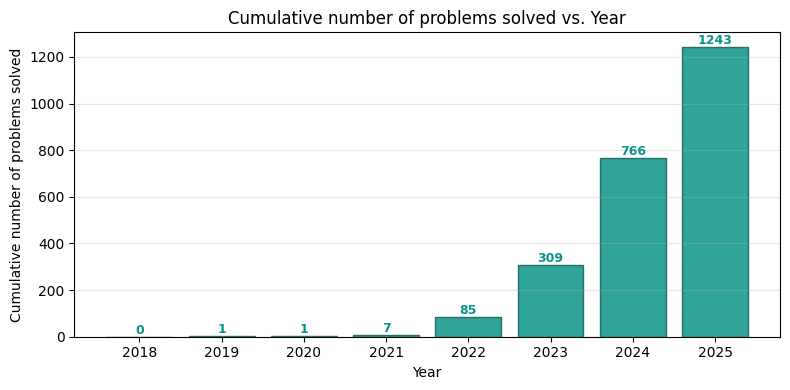

In [6]:
report_loaded["fig_cumulative_accounts"]
report_loaded["fig_cumulative_points"]
report_loaded["fig_cumulative_exercises"]
report_loaded["fig_cumulative_problems"]

### Per-year metrics (separate plots)

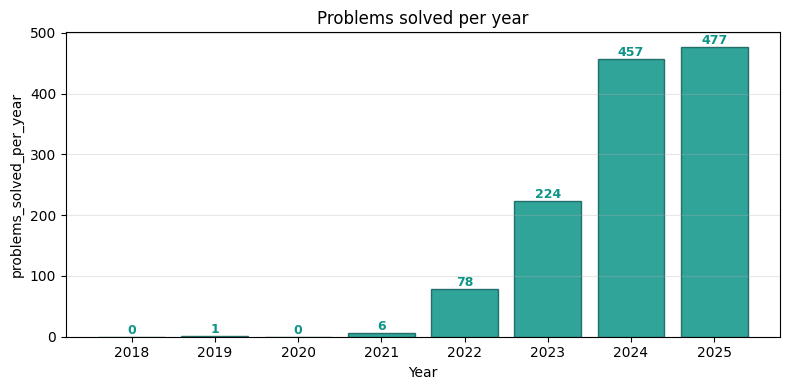

In [7]:
report_loaded["fig_per_year_signups"]
report_loaded["fig_per_year_points"]
report_loaded["fig_per_year_exercises"]
report_loaded["fig_per_year_problems"]

### Cumulative by gender (bar plots, one per metric)

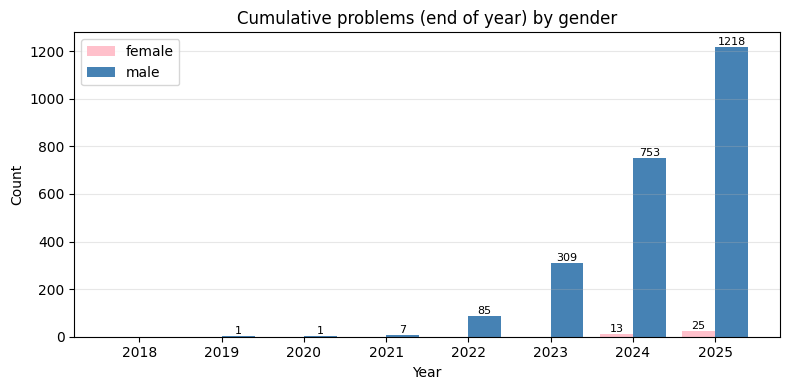

In [8]:
report_loaded["fig_cumulative_gender_signups"]
report_loaded["fig_cumulative_gender_points"]
report_loaded["fig_cumulative_gender_exercises"]
report_loaded["fig_cumulative_gender_problems"]

### Yearly metrics table

In [9]:
report_loaded["yearly_metrics_df"]

,year,signups_per_year,cumulative_accounts_eoy,points_gained_per_year,cumulative_points_eoy,exercises_completed_per_year,cumulative_exercises_eoy,problems_solved_per_year,cumulative_problems_eoy
0,2018,2,2,60,60,27,27,0,0
1,2019,3,5,252,312,51,78,1,1
2,2020,1,6,249,561,60,138,0,1
3,2021,3,9,846,1407,171,309,6,7
4,2022,22,31,6672,8079,798,1107,78,85
5,2023,86,117,21573,29652,3546,4653,224,309
6,2024,110,227,42858,72510,6203,10856,457,766
7,2025,139,366,38310,110820,5551,16407,477,1243
8,2026,46,412,18096,128916,2963,19370,179,1422


### Yearly metrics by gender

In [10]:
report_loaded["yearly_metrics_by_gender_df"]

,year,gender,metric,value
0,2018,male,signups_per_year,2
1,2018,male,cumulative_accounts_eoy,2
2,2018,female,signups_per_year,0
3,2018,female,cumulative_accounts_eoy,0
4,2019,male,signups_per_year,2
...,...,...,...,...
139,2022,female,cumulative_problems_eoy,0
140,2023,female,cumulative_problems_eoy,0
141,2024,female,cumulative_problems_eoy,13
142,2025,female,cumulative_problems_eoy,25


### Top 3 most active students per year

In [11]:
report_loaded["most_active_top3_df"]

rank,year,1st,2nd,3rd
0,2018,Abass Dabere,David Arria,NaN
1,2019,Dav A.,Éric Kouassi,Vé Saty
2,2020,Éric Kouassi,Vé Saty,Ibrahim D.
3,2021,Ibrahim D.,Aziz B.,Junior P.
4,2022,Ulrich T.,Christ Kiple,Marie-Andréa G.
5,2023,Mohamed Habib T.,Kevin E.,Savadogo A.
6,2024,Y. D.,Modeste K.,Kevin E.
7,2025,Cheik Oumar Diomandé,Jean N.,Damy Samuel Kamaté
8,2026,Harold Konan N'wozan Yao,Yoann Affran,Orlando Miller. S.


### Top 2 most active students per year by gender

2018 — Top 2 male: Abass Dabere, David Arria  |  Top 2 female: —, —
2019 — Top 2 male: Dav A., Éric Kouassi  |  Top 2 female: Vé Saty, —
2020 — Top 2 male: Éric Kouassi, Ibrahim D.  |  Top 2 female: Vé Saty, —
2021 — Top 2 male: Ibrahim D., Aziz B.  |  Top 2 female: Pascale Diby, —
2022 — Top 2 male: Ulrich T., Christ Kiple  |  Top 2 female: Marie-Andréa G., Pascale Diby
2023 — Top 2 male: Mohamed  Habib T., Kevin E.  |  Top 2 female: Jemima N'guessan, Apo Philomène N'ke
2024 — Top 2 male: Y. D., Modeste K.  |  Top 2 female: Jemima N'guessan, Faïcoth Ali
2025 — Top 2 male: Cheik Oumar Diomandé, Jean N.  |  Top 2 female: Catier Saly Traoré, Nselhy O.
2026 — Top 2 male: Harold Konan N'wozan Yao, Yoann Affran  |  Top 2 female: Catier Saly Traoré, Ornella Sebon



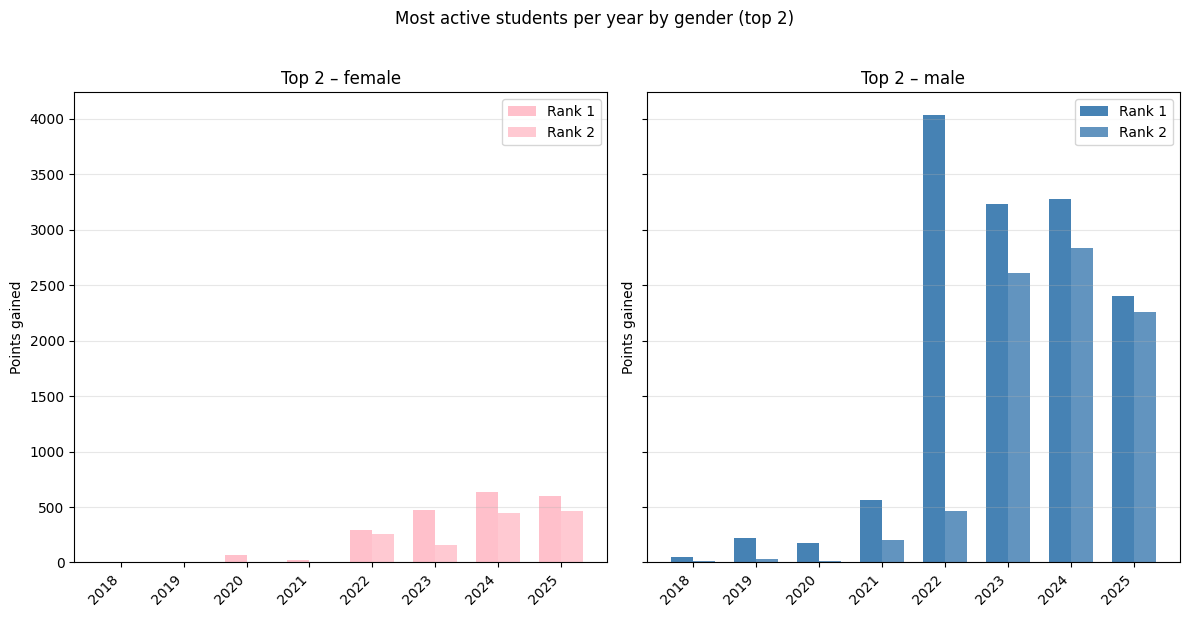

In [12]:
# Print most active by gender (names) for each year
top2_g = report_loaded["most_active_top2_by_gender_df"]
for y in sorted(top2_g["year"].unique()):
    sub = top2_g[top2_g["year"] == y]
    male = sub[sub["gender"] == "male"]
    female = sub[sub["gender"] == "female"]
    m1 = male["1st"].iloc[0] if not male.empty and pd.notna(male["1st"].iloc[0]) else "—"
    m2 = male["2nd"].iloc[0] if not male.empty and pd.notna(male["2nd"].iloc[0]) else "—"
    f1 = female["1st"].iloc[0] if not female.empty and pd.notna(female["1st"].iloc[0]) else "—"
    f2 = female["2nd"].iloc[0] if not female.empty and pd.notna(female["2nd"].iloc[0]) else "—"
    print(f"{int(y)} — Top 2 male: {m1}, {m2}  |  Top 2 female: {f1}, {f2}")
print()

report_loaded["most_active_top2_by_gender_df"]
report_loaded["fig_top2_active_by_gender"]

## Optional: export CSVs

---

In [13]:
# Optional: export report_loaded data to CSVs (run Part 2 first)
# report_loaded["yearly_metrics_df"].to_csv("yearly_metrics.csv", index=False)
# report_loaded["most_active_top3_df"].to_csv("most_active_top3.csv", index=False)
# report_loaded["most_active_top2_by_gender_df"].to_csv("most_active_top2_by_gender.csv", index=False)
# report_loaded["yearly_metrics_by_gender_df"].to_csv("yearly_metrics_by_gender.csv", index=False)

### Per-year metrics (separate plots)

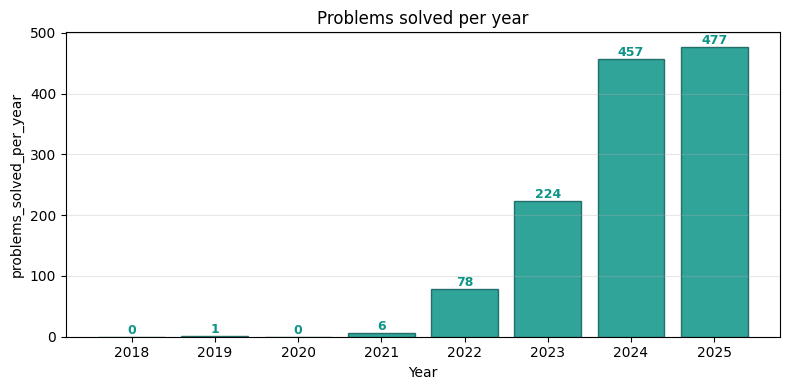

In [14]:
report_loaded["fig_per_year_signups"]
report_loaded["fig_per_year_points"]
report_loaded["fig_per_year_exercises"]
report_loaded["fig_per_year_problems"]

### Cumulative by gender (bar plots, one per metric)

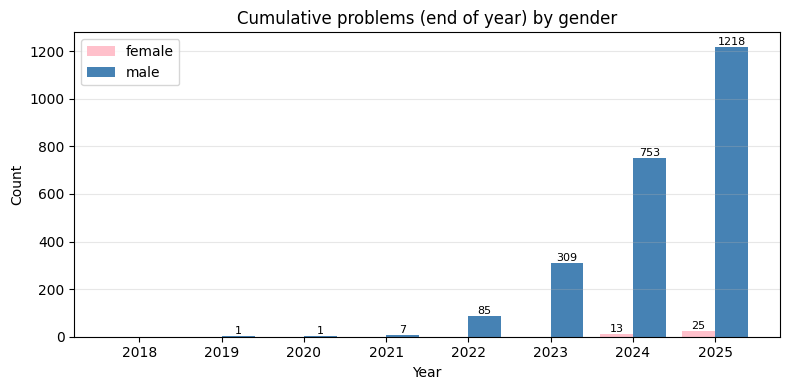

In [15]:
report_loaded["fig_cumulative_gender_signups"]
report_loaded["fig_cumulative_gender_points"]
report_loaded["fig_cumulative_gender_exercises"]
report_loaded["fig_cumulative_gender_problems"]

### Top 3 most active students per year

In [16]:
report_loaded["most_active_top3_df"]

rank,year,1st,2nd,3rd
0,2018,Abass Dabere,David Arria,NaN
1,2019,Dav A.,Éric Kouassi,Vé Saty
2,2020,Éric Kouassi,Vé Saty,Ibrahim D.
3,2021,Ibrahim D.,Aziz B.,Junior P.
4,2022,Ulrich T.,Christ Kiple,Marie-Andréa G.
5,2023,Mohamed Habib T.,Kevin E.,Savadogo A.
6,2024,Y. D.,Modeste K.,Kevin E.
7,2025,Cheik Oumar Diomandé,Jean N.,Damy Samuel Kamaté
8,2026,Harold Konan N'wozan Yao,Yoann Affran,Orlando Miller. S.


### Top 2 most active students per year by gender

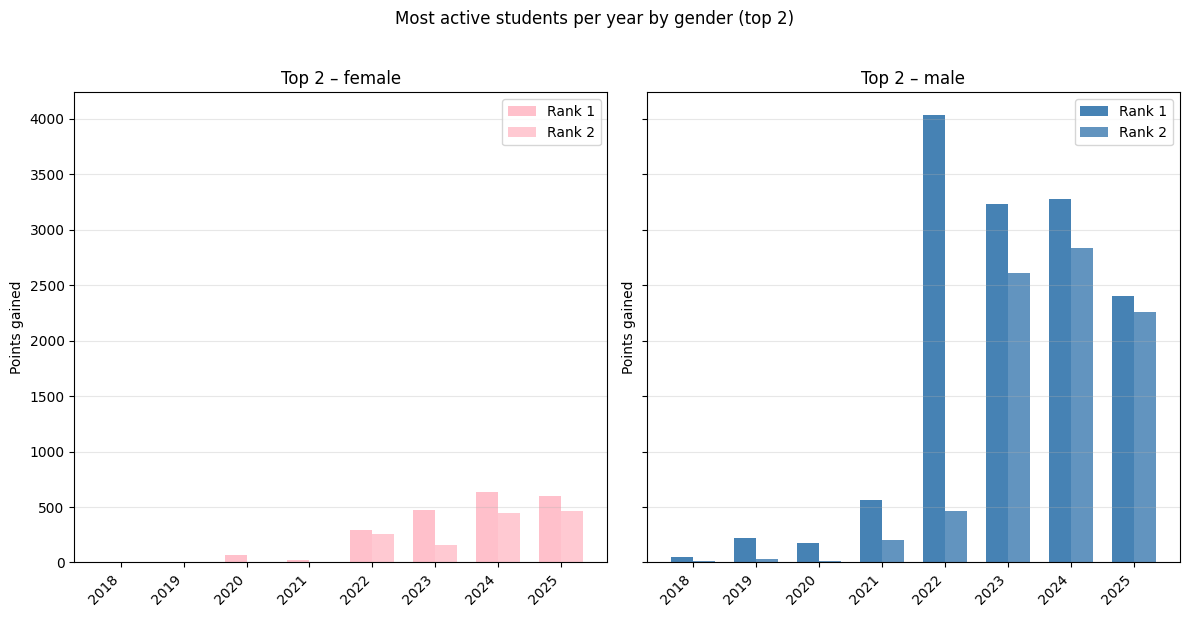

In [17]:
report_loaded["most_active_top2_by_gender_df"]
report_loaded["fig_top2_active_by_gender"]

In [18]:
# (Export options are in the Part 2 section above.)